In [1]:
%pip install nltk scikit-learn pandas numpy  WordCloud youtube_comments_scrapper google-colab-selenium

import nltk
nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.7/481.7 kB 26.3 MB/s eta 0:00:00


# Import Library

In [2]:
import nltk

import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import json

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

import google_colab_selenium as gs

from youtube_comments_scraper import YouTubeCommentScraper

# Scrape Youtube Comments

Doing Youtube Comments Scraping using premade library and saving the comments to a json file.

In [3]:
all_comments = []

In [4]:
driver = gs.Chrome() # Karena pake collab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
scraper = YouTubeCommentScraper(headless=True, timeout=10, scroll_pause_time=2, enable_logging=False, return_page_source=False)
comments = scraper.scrape_comments('https://www.youtube.com/watch?v=Rk1VmHk_kUo&t=5s', scroll=True)
print(comments)
all_comments.append(comments)

['Terimakasih Pak, materi-materi di channel Indonesia Belajar sangat membantu dalam proses pembelajaran', 'Terima kasih banyak pak. Saya guru SMP, ingin mengajarkan python untuk anak anak. Materi ini sangat membantu. Salam Indonesia Belajar', 'Ayok Semangat Belajar', 'terima kasih tutorialnya, jelas dengan suara adem', 'Terimakasih Pak, materi2 di channel bapak sangat bermanfaat dan saya sangat menyukai intonasi bicara bapak yg membuat semangat belajar dan ngga bikin ngantuk', 'Luar biasa sangat bermanfaat', 'Yg ditunggu2 akhirnya datang jg', 'semoga sehat selalu mas, teruslah memberikan yang terbaik', 'Marvelous! ditunggu kelanjutannya', 'Terima Kasih Ilmunya yang sangat bermanfaat', 'makasih pak, ini tutorial yang lagi dicari. masih part awal nih', 'Thank you sir, i love you so much', 'Semangat Semangat', 'Terimakasih banyak pak', 'Terimakasih', 'ayo pak, udh ngga sabar hehe', 'Lanjutkan pak.. biar 2021 makin semangat belajar.', 'Mas Budi kaosnya match banget hehe', 'Makasih pak', 's

In [6]:
scraper = YouTubeCommentScraper(headless=True, timeout=10, scroll_pause_time=2, enable_logging=False, return_page_source=False)
comments = scraper.scrape_comments("https://www.youtube.com/watch?v=mSO2hJln0OY&t=31s", scroll=True)
print(comments)
all_comments.append(comments)

['pak, saya kurang ngerti konsep data train test, bagaimana kok tiba2 muncul hasil? itu data train dan test nya diapakan sama system?', 'semoga terus mencedaskan INDONESIA BELAJAR', 'Maaf mas, sedikit masukan untuk Pronunciation dalam bahasa Inggris mohon di benarkan,  kadang kala dlm pembelajaran ini sy hanya mendengar saja dan tidak melihat text. \n\nTerima kasih utk sharing ilmunya, mohon maaf apabila tdk berkenan', 'saat print X Train dan X test, itu hasilnya ada 2 parameter, param yg ke dua itu apa ya?', 'Nice video. Emang harus belajar dari dasarnya dulu, kayak gini. Subscribing.', 'sudah sampai sini hehe, waduh gaada 480p ya', 'Di kampus langsung dapatnya advance machine learning jadi kesulitan mengikuti dosen, terima kasih videonya memberikan banyak pencerahan', "KeyError: 'key of type tuple not found and not a MultiIndex' permisi pak ini knp ya saat visualisasi data error spt ini, saya pakai dataframe sebagai panggilan kolom tabel dataset pada feature dan target", 'pak saya ma

In [7]:
scraper = YouTubeCommentScraper(headless=True, timeout=10, scroll_pause_time=2, enable_logging=False, return_page_source=False)
comments = scraper.scrape_comments("https://www.youtube.com/watch?v=tiREcHrtDLo&t=24s", scroll=True)
print(comments)
all_comments.append(comments)

['Selama ini belajar pake kursus online berbayar ga paham paham konsep model ini, bersyukur nemu channel ini bisa dengan mudah langsung ngerti, terimakasih', 'MasyaAllah, penjelasan bapak meski 3 tahun yang lalu sangat membantu saya dalam belajar machine learning untuk pemula. terimakasih banyak pak, semoga sehat dan berkah selalu. aamiin....', 'bener2 mudah dipahami, saya pernah ikutan bootcamp Machine Learning dan kurg paham sama materinya. bersyukur bggt ketemu playlist ini. Terimakasih banyak pak\n\nmungkin boleh request ke tensorflow pak hehe', 'Bermanfaat banget mas ! kebetulan saya lagi belajar Machine Learning tapi bingung mulai dari mana', 'bisa belajar banyak disini, mudah dipahami, terus hadirkan materi machine learning yang baru, mas.', 'Mantap nih mudah diikuti', 'Mantap baru kemaren, skrg udh rilis lg aja.', 'terimakasih mas akhirnya say aham', 'Done', 'pingin request kak, machine learning tp menggunakan library tensorflow, soalnya masih jarang tutorial tensorflow yg berb

In [8]:
scraper = YouTubeCommentScraper(headless=True, timeout=10, scroll_pause_time=2, enable_logging=False, return_page_source=False)
comments = scraper.scrape_comments("https://www.youtube.com/watch?v=lcjq7-2zMSA", scroll=True)
print(comments)
all_comments.append(comments)

['multiple linear regression juga dong mas dibuat tutorial ya, biar tau perbedaan diantara keduanya mas', 'tema sesulit ini jadi gampang di cerna dan dipahami berkat team indonesia belajar thanks yah!!!', 'Ternyata benar, machine learning hubungannya erat dengan statistika.', 'keren nih mudah diikuti. terima kasih banyak indonesia belajar.', 'terimakasih mas, bermanfaat sekali ilmunya.', 'Mohon bahas Support Vector Regression dengan kernel-kernelnya', 'Mohon nanti setelah materi semua machine learning di ajarkan... Mohon ada projek tentang dunia kerja full ngebahas dunia kerja di data scientists', '33:07ValueError: Found input variables with inconsistent numbers of samples: [5, 4]\n\npadahal udh persis kyk di video', 'izin belajar pak', 'Mohon belajar jaringan syaraf tiruan khusus algoritma multilayer', 'mantap bang.. kira2 ini sampe ke materi classification naive bayes, svm dll ga bang?', 'bang ajari confusion matrix donk\nyang mana videonya plis lanjut pembelajaran machine learning',

In [9]:
scraper = YouTubeCommentScraper(headless=True, timeout=10, scroll_pause_time=2, enable_logging=False, return_page_source=False)
comments = scraper.scrape_comments("https://www.youtube.com/watch?v=4zARMcgc7hA", scroll=True)
print(comments)
all_comments.append(comments)

['bang saya mau nanya nih masih bingung pas labelingnya.. apakah target/output harus selalu 1 dimensi ?? terus kalo features/input harus selalu 2 dimensi bang??', 'Penjelasan memang cukup sederhana. Tapi yang perlu diperhatikan adalah. Cara menganalisa nilai2 evaluasi akurasi, precision, recall, f1_score, mcc. Apa manfaat dan implikasinya bila score yg didapatkan dg nilai tertentu.', 'Mantap, baru bisa nyimak nih', 'penjelasannya sangat lengkap... mantap', 'Thank you bang. Akhirnya ngerti konsep nya.', 'Pak, saya sudah nonton sampai sejauh ini dan sangat membantu & clear penjelasannya, mohon untuk dilanjutkan terus setelah sesi 16, untuk materi Machine Learning yang lebih advance dan penerapannya, terimakasih...', 'Terima kasih pak, penjelasannya sangat mudah dimengerti, sehat selalu pak', 'Pak ijin untuk next video penjelasan classification menggunakan xgboost', 'tutorial mantul banget, mohon pak di bahas selanjutnya model klasifikasi yg sering di pakai di Indonesia  C4.5 & Naive Baye

In [10]:
# Transform all coment into a single list
all_comments = [comment for comments in all_comments for comment in comments]

In [11]:
# Save all comment into a json
with open('comments.json', 'w') as f:
    json.dump(all_comments, f)

print("All comments saved in comments.json")

All comments saved in comments.json


# Preprocess Comments

## Lowercase

In [12]:
preprocessed_comments = all_comments

preprocessed_comments = [comment.lower() for comment in preprocessed_comments]

Lowercase all comments to avoid case sensitivity. (e.g. "Hello" and "hello" are considered the same)

## Remove Punctuation

In [13]:
import string

# Remove punctuation
preprocessed_comments = [comment.translate(str.maketrans('', '', string.punctuation)) for comment in preprocessed_comments]

Remove punctuation from comments to avoid unnecessary noise. (e.g. "Hello!" and "Hello" are considered the same)

## Remove Special Characters

In [14]:
preprocessed_df = pd.DataFrame(preprocessed_comments, columns=['comments'])
preprocessed_df['comments'] = preprocessed_df['comments'].str.replace('[^\w\s]','')

preprocessed_df.sample(5)

,comments
27,data enthusiast merapatt
187,kak untuk penentuan nilai k nya ini apakah ter...
82,bener2 mudah dipahami saya pernah ikutan bootc...
192,saya ingin bertanya kenapa evaluasi modelnya t...
99,maaf pak izin bertanya saya pemula sedang ber...


Remove special characters from comments to avoid unnecessary noise. (e.g. "Hello!" and "Hello" are considered the same)

## Tokenization

In [19]:
# Tokenize the comments
preprocessed_df['tokenized_comments'] = preprocessed_df['comments'].apply(word_tokenize)

# Remove stopwords (indonesia)
stop_words = set(stopwords.words('indonesian'))
preprocessed_df['tokenized_comments'] = preprocessed_df['tokenized_comments'].apply(lambda x: [item for item in x if item not in stop_words])

# Show the first 5 rows
preprocessed_df.head()

,comments,tokenized_comments
0,terimakasih pak materimateri di channel indone...,"[terimakasih, materimateri, channel, indonesia..."
1,terima kasih banyak pak saya guru smp ingin me...,"[terima, kasih, guru, smp, mengajarkan, python..."
2,ayok semangat belajar,"[ayok, semangat, belajar]"
3,terima kasih tutorialnya jelas dengan suara adem,"[terima, kasih, tutorialnya, suara, adem]"
4,terimakasih pak materi2 di channel bapak sanga...,"[terimakasih, materi2, channel, bermanfaat, me..."


Tokenize comments into words to prepare for further processing. By separating comments into words, we can analyze the comments more effectively. (e.g. "Hello world" -> ["Hello", "world"])

# WordCloud

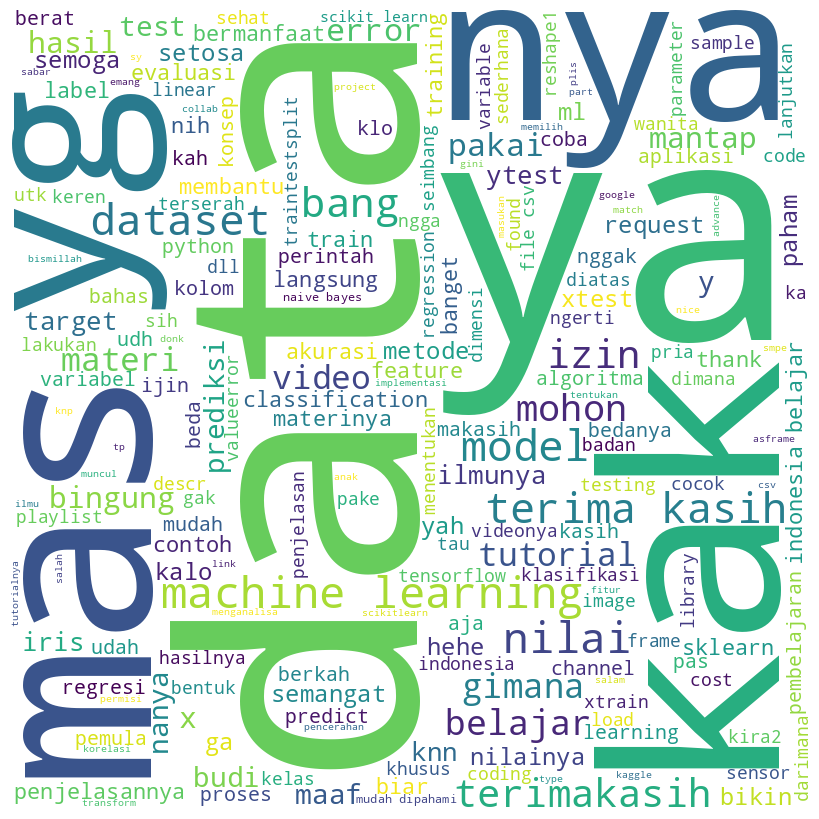

In [20]:
wordcouloud = WordCloud(width = 800, height = 800, background_color='white').generate(' '.join(preprocessed_df['tokenized_comments'].sum()))

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcouloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

Based on the wordcloud, we can see that

High-Frequency Words:

    "data" and "dataset": These are central, suggesting that data-related questions or discussions are very frequent.
    "model" and "machine learning": Emphasize the focus on building and working with machine learning models.
    "kak" and "mas": Common Indonesian terms for addressing someone informally, often used in educational or community support contexts.
    "nilai" and "hasil": Relate to "score" or "results," likely indicating frequent discussions on model evaluation metrics or performance outcomes.
    "target," "prediksi": Words associated with predictive modeling and target variables.

Learning and Help-Seeking Language:

    "belajar" (learning), "tutorial," "penjelasannya" (explanation): These words suggest an emphasis on learning and tutorials, indicating users are looking for guidance, tutorials, or explanations.
    "terima kasih" (thank you) and "izin nanya" (permission to ask): Politeness is evident, suggesting a supportive community where users feel comfortable asking questions.

Common Machine Learning Terms:

    Terms like "train," "test," "feature," "label," "classification," and "regression" show up, which are standard terminology in machine learning.
    "sklearn," "knn," "SVM": References to specific algorithms or libraries, like scikit-learn, K-Nearest Neighbors, and Support Vector Machines.

Expressions of Frustration or Confusion:

    Words like "bingung" (confused), "error," "kenapa" (why), and "gimana" (how) reflect common struggles or confusion with machine learning concepts, syntax, or errors in code.

Expressions of Encouragement or Gratitude:

    "semangat" (spirit/enthusiasm), "mantap" (great/awesome), "terima kasih" (thank you): These positive words highlight encouragement, gratitude, and supportive interactions within the community.

# Vectorization

## Count Vectorization

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the count vectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the processed titles
count_data = count_vectorizer.fit_transform(preprocessed_df['tokenized_comments'].apply(lambda x: ' '.join(x)))


Count Vectorization is a technique to convert text data into numerical data. It counts the frequency of each word in the text data and converts it into a matrix. (e.g. "Hello world" -> [1, 1])

In [22]:
count_data.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

## TF-IDF Vectorization

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the processed titles
tfidf_data = tfidf_vectorizer.fit_transform(preprocessed_df['tokenized_comments'].apply(lambda x: ' '.join(x)))

TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization is a technique to convert text data into numerical data. It calculates the importance of each word in the text data based on its frequency in the document and the entire corpus. (e.g. "Hello world" -> [0.5, 0.5])

In [24]:
tfidf_data.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])